# 데이터 분석 실무1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


# 기온데이터 분석

- 1907년부터 2018년3월까지의 서울 기온 데이터
- seoul.csv, encoding='cp949' 또는 encoding='euc-kr'(cp949는 euc-kr을 포함하고 있음)

In [5]:
df = pd.read_csv('./datas/seoul.csv', encoding='cp949')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39926 entries, 0 to 39925
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   날짜       39926 non-null  str    
 1   지점       39926 non-null  int64  
 2   평균기온(℃)  39170 non-null  float64
 3   최저기온(℃)  39169 non-null  float64
 4   최고기온(℃)  39168 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.5 MB


In [7]:
df.describe()

,지점,평균기온(℃),최저기온(℃),최고기온(℃)
count,39926.0,39170.000000,39169.000000,39168.000000
mean,108.0,11.672716,7.374237,16.684921
std,0.0,10.664129,10.887584,10.996621
min,108.0,-19.200000,-23.100000,-16.300000
25%,108.0,2.600000,-1.500000,7.100000
50%,108.0,12.900000,7.900000,18.500000
75%,108.0,21.200000,17.000000,26.200000
max,108.0,33.100000,28.800000,38.400000


In [8]:
df['날짜'].describe()

count          39926
unique         39926
top       1907-10-01
freq               1
Name: 날짜, dtype: object

## 실습 1. 가장 더운날은 언제입니까?

In [12]:
df['최고기온(℃)'].max()

np.float64(38.4)

In [10]:
df['최고기온(℃)'] == df['최고기온(℃)'].max()

0        False
1        False
2        False
3        False
4        False
         ...  
39921    False
39922    False
39923    False
39924    False
39925    False
Name: 최고기온(℃), Length: 39926, dtype: bool

In [14]:
df.loc[df['최고기온(℃)'] == df['최고기온(℃)'].max()]

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
31277,1994-07-24,108,33.1,28.1,38.4


- 정렬해서 해결하는 방법

In [ ]:
df.sort_values('최고기온(℃)', ascending=False).head(1)      # NaN 데이터는 마지막에 배치됨      # 정렬 된 순서를 다 보고 싶다면 head 지우고

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
31277,1994-07-24,108,33.1,28.1,38.4


## 실습 2. 최고기온을 히스토그램으로 나타내되, bin의 범위를 4도로 만들어서, 히스토그램으로 보여주세요.

In [19]:
df['최고기온(℃)'].min()

np.float64(-16.3)

In [20]:
df['최고기온(℃)'].max()

np.float64(38.4)

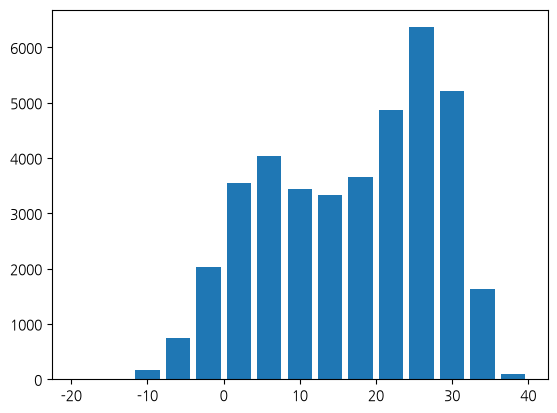

In [52]:
# 4도 단위로 구간설정.  시작값, 끝값을 먼저 설정하면 된다. 
bin_width = 4

# 최대값 최소값을 그대로 사용하면 차트 보는 것이 불편하고 bin의 경계가 어색해짐
min_value = np.floor(df['최고기온(℃)'].min() / bin_width) * bin_width     # 소수점 버림
max_value = np.ceil(df['최고기온(℃)'].max() / bin_width) * bin_width      # 소수점 올림

#print(min, max)

total_bins = np.arange(min_value, max_value + bin_width, bin_width)

plt.hist(data = df, x = '최고기온(℃)', rwidth= 0.8, bins = total_bins)
plt.show()

In [24]:
plt.show()

In [30]:
df

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
0,1907-10-01,108,13.5,7.9,20.7
1,1907-10-02,108,16.2,7.9,22.0
2,1907-10-03,108,16.2,13.1,21.3
3,1907-10-04,108,16.5,11.2,22.0
4,1907-10-05,108,17.6,10.9,25.4
...,...,...,...,...,...
39921,2018-03-24,108,7.6,4.0,13.1
39922,2018-03-25,108,9.6,4.6,16.9
39923,2018-03-26,108,11.0,5.3,18.1
39924,2018-03-27,108,13.3,7.7,20.0


## 실습 3. 위에서는 모든 날짜에 대한 데이터 입니다.  
## 그러면! 2014년도 부터의 데이터를 기준으로, bin의 범위를 4도로 만들어서, 히스토그램으로 보여주세요.

In [33]:
df['날짜'] >= '2014-01-01'

0        False
1        False
2        False
3        False
4        False
         ...  
39921     True
39922     True
39923     True
39924     True
39925     True
Name: 날짜, Length: 39926, dtype: bool

In [38]:
df_2014 = df.loc[df['날짜'] >= '2014-01-01', :]

In [39]:
df_2014

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
38378,2014-01-01,108,4.0,0.3,7.9
38379,2014-01-02,108,1.5,-1.3,6.2
38380,2014-01-03,108,2.3,-1.1,7.3
38381,2014-01-04,108,-0.1,-3.7,5.6
38382,2014-01-05,108,-0.8,-4.3,3.8
...,...,...,...,...,...
39921,2018-03-24,108,7.6,4.0,13.1
39922,2018-03-25,108,9.6,4.6,16.9
39923,2018-03-26,108,11.0,5.3,18.1
39924,2018-03-27,108,13.3,7.7,20.0


- x축의 구분 범위를 4로 맞춰서 bins 만들기

In [41]:
df_2014['최고기온(℃)'].min()

np.float64(-10.7)

In [42]:
df_2014['최고기온(℃)'].max()

np.float64(36.6)

In [ ]:
min_value = np.floor(df_2014['최고기온(℃)'].min() / bin_width) * bin_width
max_value = np.ceil(df_2014['최고기온(℃)'].max() / bin_width) * bin_width

spc_bins = np.arange(min_value, max_value + bin_width, bin_width)

In [ ]:
spc_bins

array([-12.,  -8.,  -4.,   0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,
        32.,  36.,  40.])

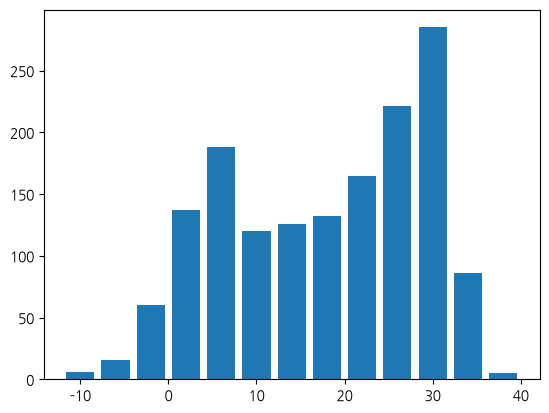

In [50]:
spc_bins = np.arange(min_value, max_value + bin_width, bin_width)
plt.hist(data= df_2014, x='최고기온(℃)', rwidth=0.8, bins= spc_bins)
plt.show()

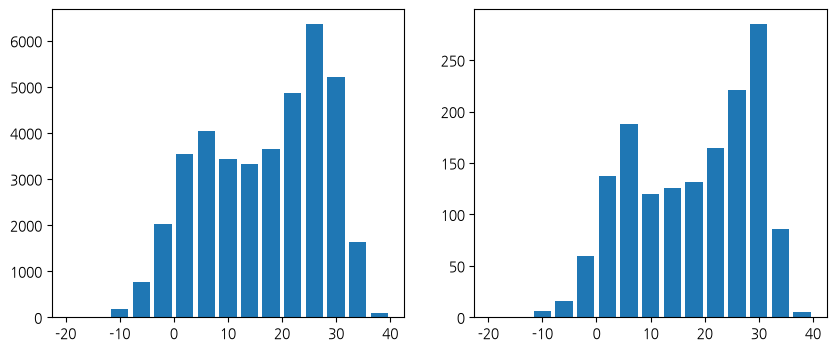

In [54]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(data = df, x = '최고기온(℃)', rwidth=0.8, bins = total_bins)

plt.subplot(1, 2, 2)
plt.hist(data = df_2014, x = '최고기온(℃)', rwidth=0.8, bins = total_bins)

plt.show()

## 실습 4.  2017-08-01 ~ 2017-08-15 사이의 데이터에서,
## 날짜를 x축,  최고기온을 y축으로 스케터로 나타내세요.

In [56]:
( df['날짜'] >= '2017-08-01' )  &  ( df['날짜'] <= '2017-08-15' )

0        False
1        False
2        False
3        False
4        False
         ...  
39921    False
39922    False
39923    False
39924    False
39925    False
Name: 날짜, Length: 39926, dtype: bool

In [57]:
df_new = df.loc[ ( df['날짜'] >= '2017-08-01' )  &  ( df['날짜'] <= '2017-08-15' ), ]

In [58]:
df_new

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
39686,2017-08-01,108,28.6,24.1,33.0
39687,2017-08-02,108,30.0,26.6,33.0
39688,2017-08-03,108,30.2,27.2,33.9
39689,2017-08-04,108,30.3,25.9,35.3
39690,2017-08-05,108,31.4,27.6,34.8
39691,2017-08-06,108,29.8,28.2,34.0
39692,2017-08-07,108,29.2,26.4,34.4
39693,2017-08-08,108,28.2,25.5,31.0
39694,2017-08-09,108,27.6,24.6,32.0
39695,2017-08-10,108,24.8,23.9,26.3


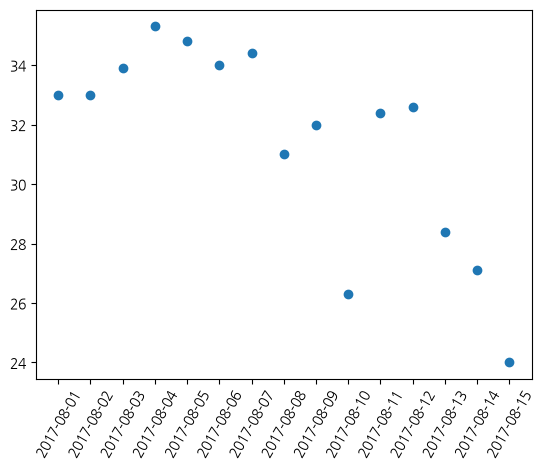

In [ ]:
plt.scatter(data = df_new, x = '날짜', y = '최고기온(℃)')
plt.xticks(rotation = 60)   # 아래 x축 설명 각도
plt.show()